In [22]:
%run functions_dbs.py

fs = 12
%matplotlib

Using matplotlib backend: MacOSX


In [23]:
# load measurement file with all measurements included
file = 'Complete_T2.xlsx'
SoftwareFile = input('is it a measurement file directly from the software? ')

is it a measurement file directly from the software? False


In [24]:
if SoftwareFile == 'True':
    # raw measurement file pre-processed and saved per default as rawData file
    dsheets = _loadFile4GUI(file=file)
else:
    # old version with pre-processed files:
    dsheets = pd.read_excel(file, sheet_name=None)

print('available sheet names', list(dsheets.keys()))

available sheet names ['O2', 'pH', 'H2S', 'Ep', 'H2S_all', 'pH_all', 'O2_all', 'Ep_all']


In [25]:
sheet_select = input('what is the sheet name? --> ')

what is the sheet name? --> pH_all


Define parameter for analysis

In [26]:
# global parameter
plot_res = False
type_fig = ['png', 'jpg']

In [86]:
SoftwareFile = False
if SoftwareFile == 'True':
    ddata = dsheets[sheet_select]
else:
    ddata = dsheets[sheet_select].set_index('Nr')
    
# ----------------------------------------------------------------------------------
# list all available cores for O2 sheet
ls_core = list(dict.fromkeys(ddata['Core'].to_numpy()))

# import all measurements for given parameter
dpH_dcore, ls_nr, ls_colname = load_measurements(dsheets=ddata, ls_core=ls_core, para=sheet_select)

# manually defined swi for surface correction
swi = 2500
for c in dpH_dcore.keys():
    for s in dpH_dcore[c].keys():
        ynew = dpH_dcore[c][s].index - swi
        dpH_dcore[c][s].index = ynew
        
dfig = plot_pHProfile(ls_core=ls_core, dic_dcore=dpH_dcore, plot_res=plot_res)

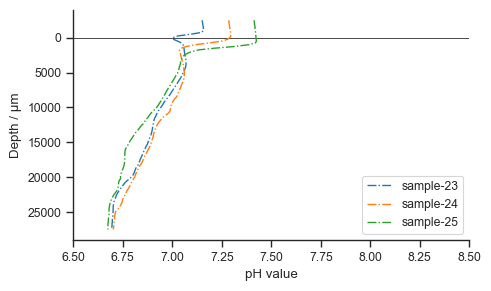

In [87]:
dfig[8]

In [ ]:
# copy dictionary between jupyter notebooks
%store dpH_dcore

In [ ]:
# save figure 
for c in dfig.keys():
    for t in type_fig:
        print('20220104_Results/{}/pH-DepthProfile-{}.'.format(file.split('_')[1].split('.')[0], c)+t)
        dfig[c].savefig('20220104_Results/{}/pH-DepthProfile-{}.'.format(file.split('_')[1].split('.')[0], c)+t)